# Final Project Notebook

Use the follow cells prompts to complete the final project for the course. Everything you need should be present in this notebook or previous notebooks we've used in class. You can work together as needed. 

 - You will need to name your own dataset and use that name throughout
 - There are sections where you need to make changes the code and insert new code this will be noted in the code provided
 - You may get frustrated along the way, this is totally normal, just remember even small changes to the code make a huge difference. 

## Question Fork the Repository
i. Include a screenshot of the forked repo in your GitHub account

To fork the repository:
1. Go to https://github.com/NovaVolunteer/ds1001_final
2. Click the "Fork" button in the top right corner
3. The repo will be forked to your GitHub account
4. Take a screenshot of your forked repository

### You should now be able to open your cloned repo in google collab, use the code below. 

### It's very helpful to have the variable inspector open while you go through this process. To do so go to tools>command palette>show variable inspector

### It's also helpful to open up the folder tree on the left menu bar. Just click on the folder icon and then the ds1001_final folder. The data is located in the data folder in the processed sub-folder. 

In [1]:
!git clone "https://github.com/username/repository.git"
# This script clones a GitHub repository using Git command line tool. 
# Insert the path to your desired repository in place of the URL.

Cloning into 'repository'...
remote: Repository not found.
fatal: repository 'https://github.com/username/repository.git/' not found


## Systems

In [2]:
# Activate the finalproj environment
!source ds1001_final/ds1001_final/finalproj/bin/activate

/bin/bash: line 1: ds1001_final/ds1001_final/finalproj/bin/activate: No such file or directory


In [18]:
!free -h
!df -h

               total        used        free      shared  buff/cache   available
Mem:           7.8Gi       3.4Gi       178Mi        61Mi       4.5Gi       4.3Gi
Swap:             0B          0B          0B


Filesystem      Size  Used Avail Use% Mounted on
overlay          32G   11G   20G  37% /
tmpfs            64M     0   64M   0% /dev
shm              64M     0   64M   0% /dev/shm
/dev/root        29G   19G   11G  63% /vscode
/dev/loop4       32G   11G   20G  37% /workspaces
/dev/sdb1        44G  2.1G   40G   5% /tmp


In [16]:
pip show scikit-learn


Name: scikit-learn
Version: 1.8.0
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: /usr/local/python/3.12.1/lib/python3.12/site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: fairlearn
Note: you may need to restart the kernel to use updated packages.


In [3]:
### You can use this command to list all the packages in your environment
!pip list

Package                   Version
------------------------- -----------
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.2.0
attrs                     25.4.0
Automat                   25.4.16
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.5
colorama                  0.4.6
comm                      0.2.3
constantly                23.10.4
contourpy                 1.3.3
cryptography              47.0.0
cssselect                 1.4.0
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fairlearn                 0.13.0
fastjsonschema            2.21.2
filelock                  3.29.0
fonttools   

In [4]:
!pip install "XX"
!pip install pandas numpy matplotlib seaborn scikit-learn fairlearn

#You'll likely need to install the fairlearn packages, if not already installed.
#Are there additional packages to install? (Cross check with the list above to 
# ensure all packages are installed)


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


### Check !pip list again to confirm installations

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import fairlearn.metrics
from fairlearn.metrics import MetricFrame
from fairlearn.metrics import count, true_positive_rate, false_positive_rate, selection_rate, demographic_parity_ratio


## Design: Data prep and exploration 

In [6]:
bankInfo = pd.read_csv('../data/processed/bank_final.csv') # the data is the data folder, 
#you'll need to use the correct path to the dataset. 
print(bankInfo.shape)
# How many rows are in the dataframe? How many columns?

(43628, 13)


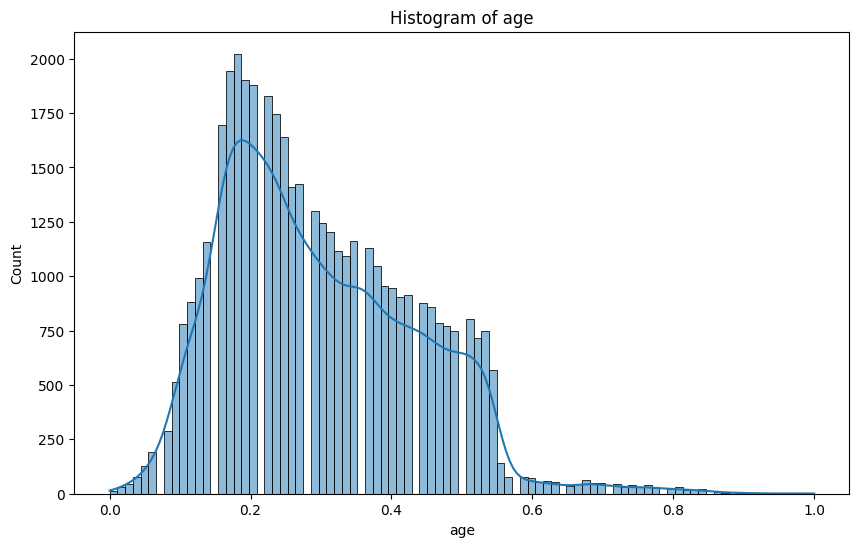

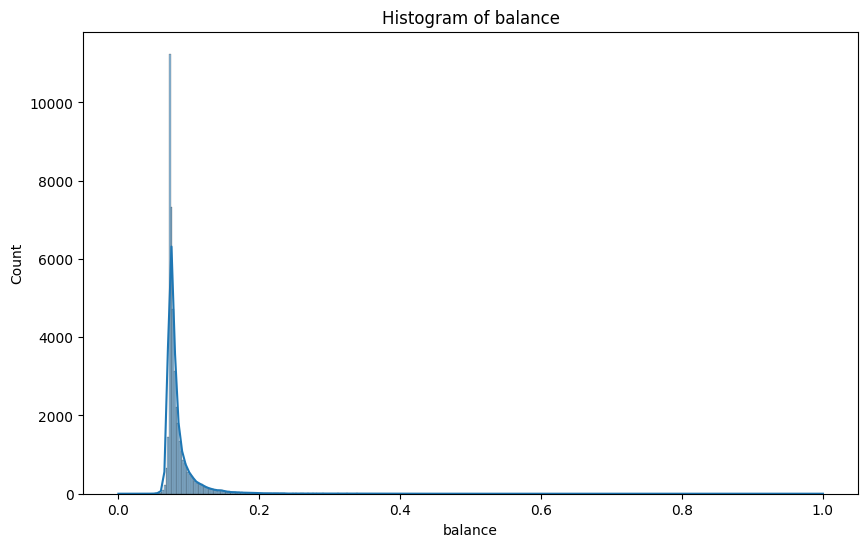

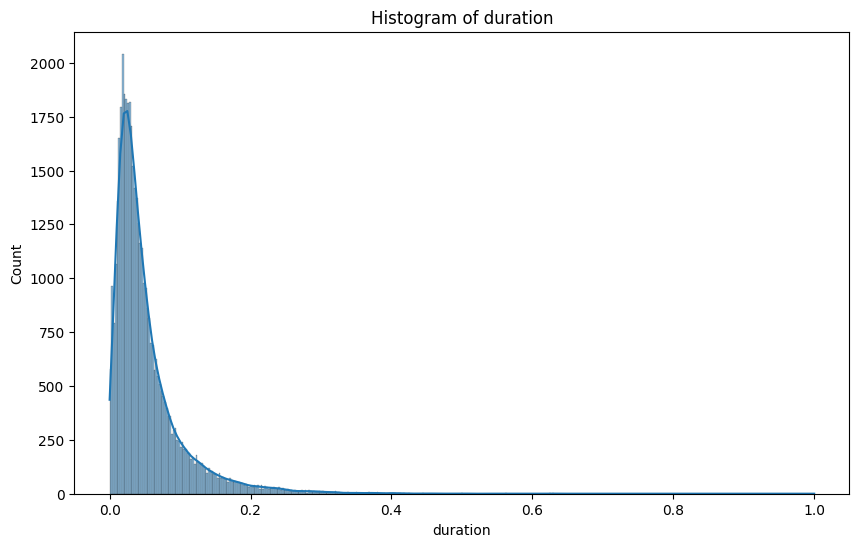

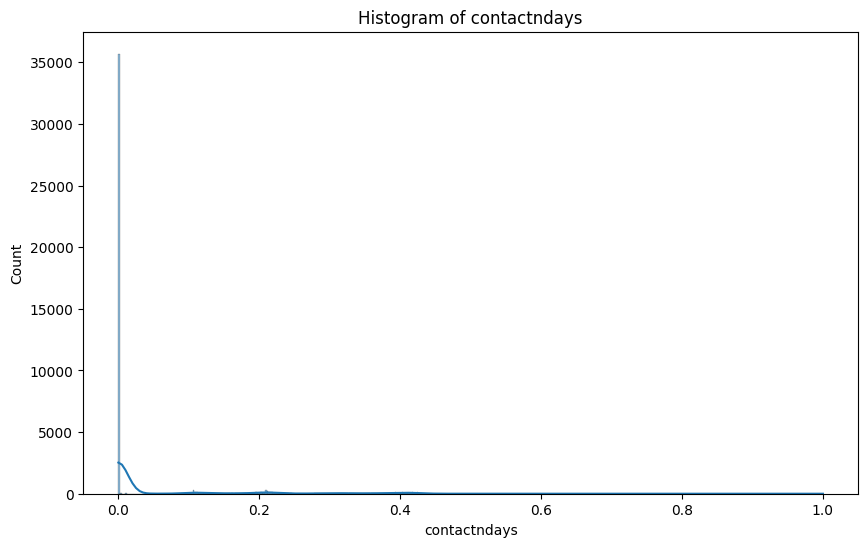

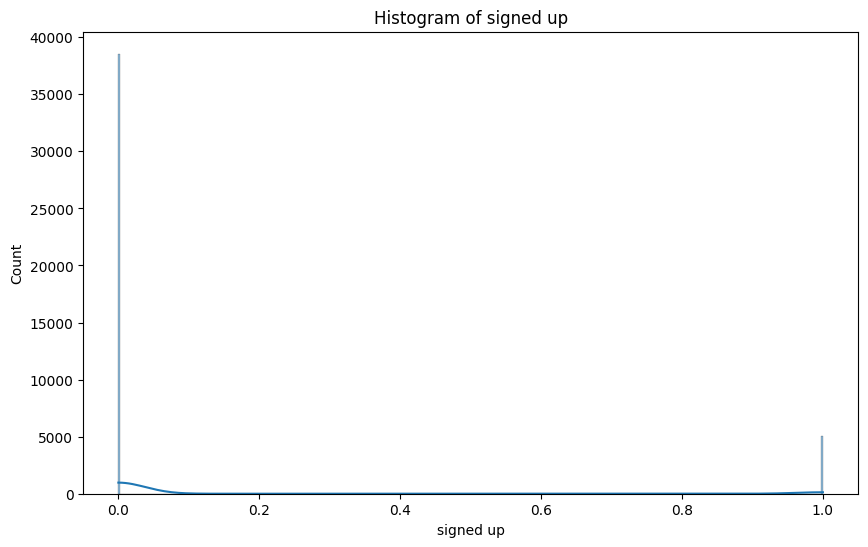

In [25]:
# Explore the variables a bit more, create histograms for the numerics values and bar charts for the categorical.
# Histograms for numeric variables
numeric_columns = bankInfo.select_dtypes(include=['number']).columns
for col in numeric_columns: 
    plt.figure(figsize=(10, 6))
    sns.histplot(bankInfo[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()  



/tmp/ipykernel_1762/2329509839.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = bankInfo.select_dtypes(include=['object', 'category']).columns


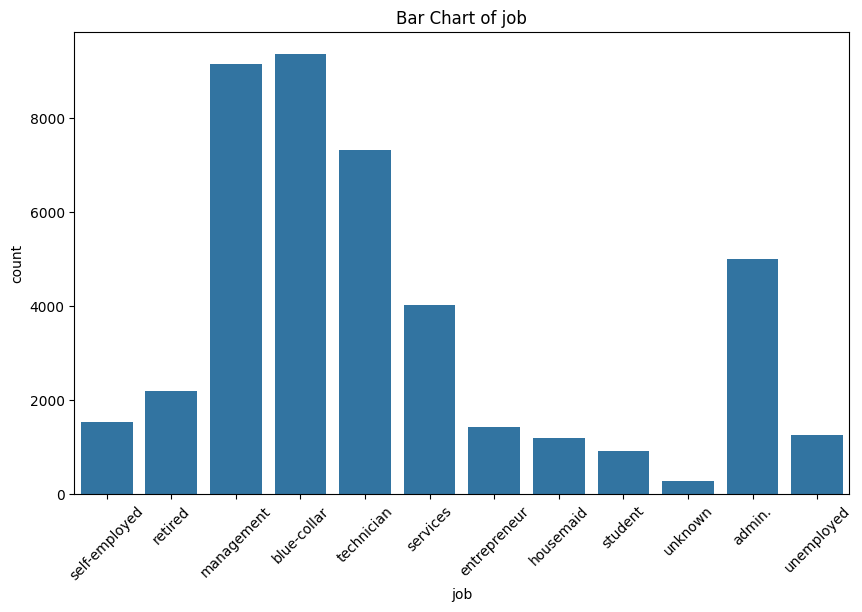

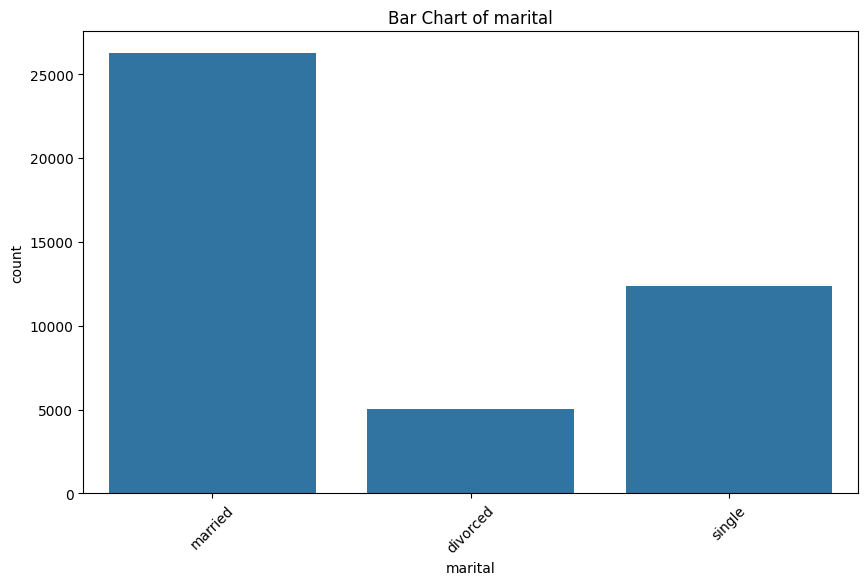

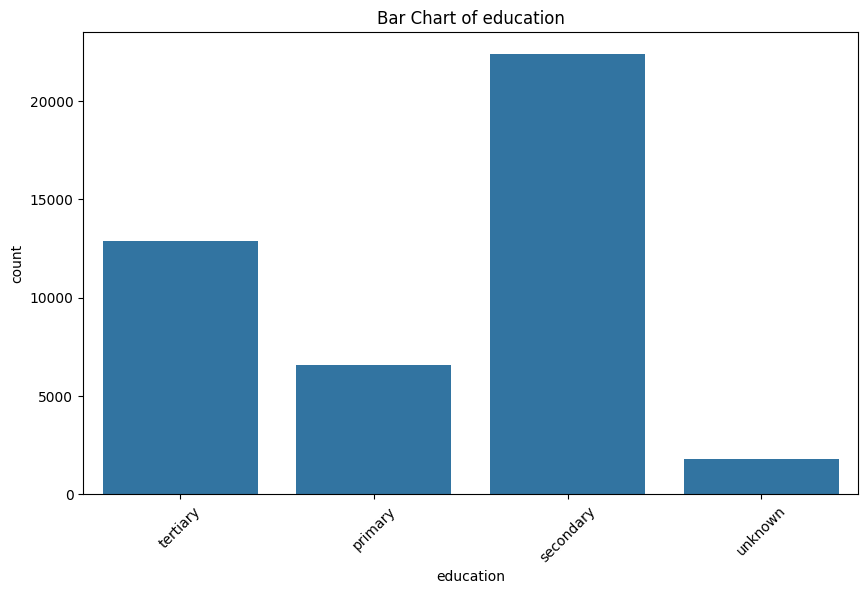

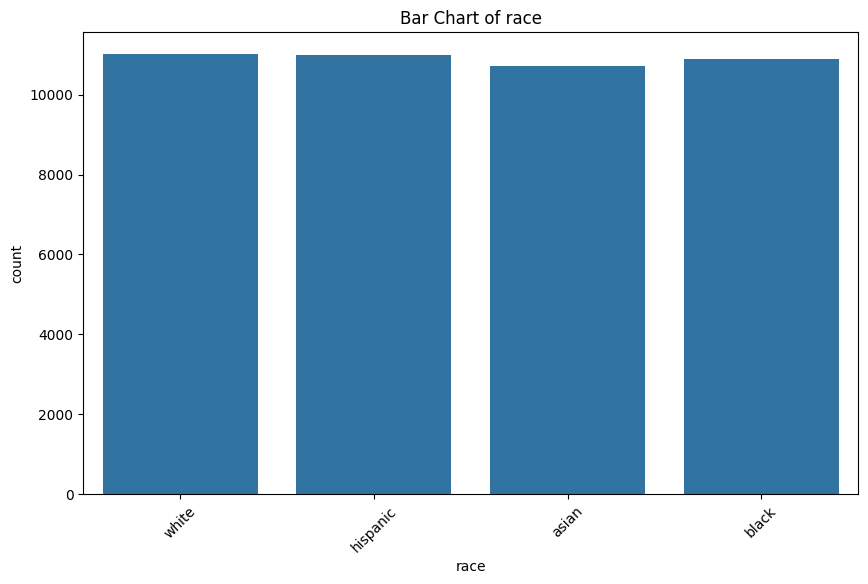

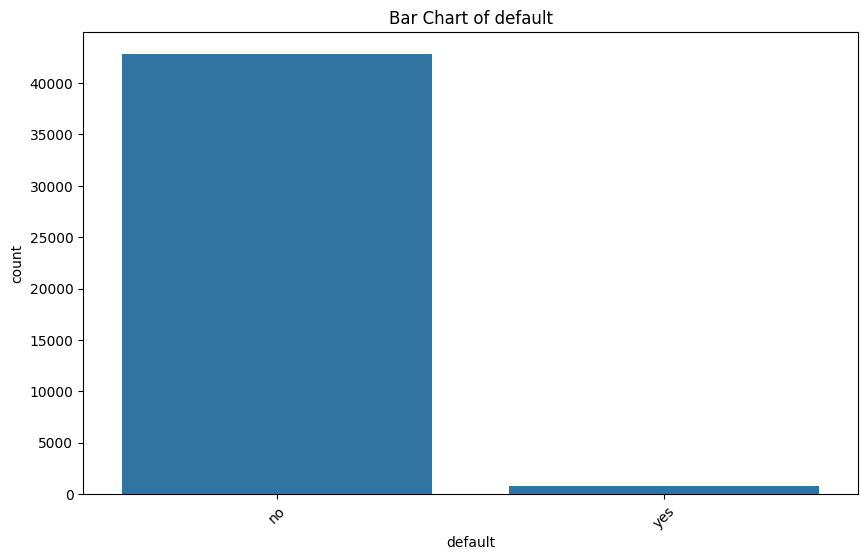

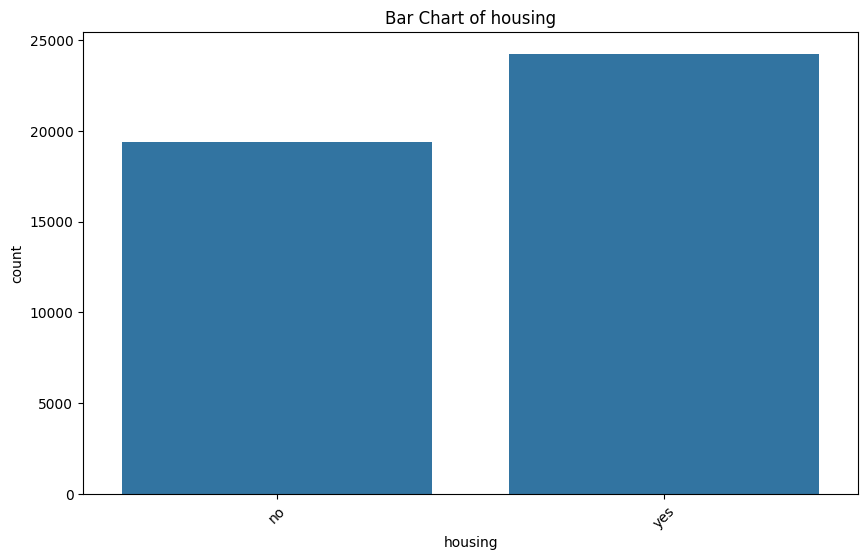

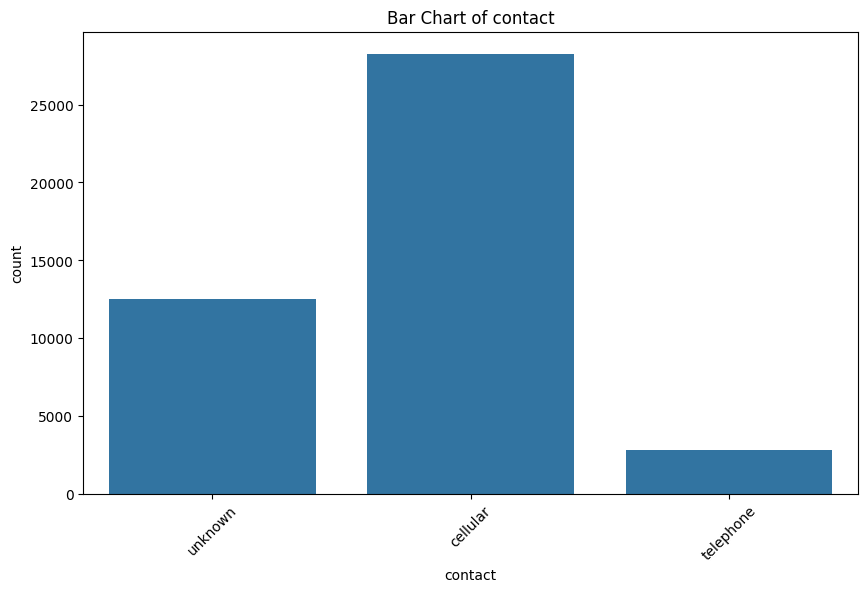

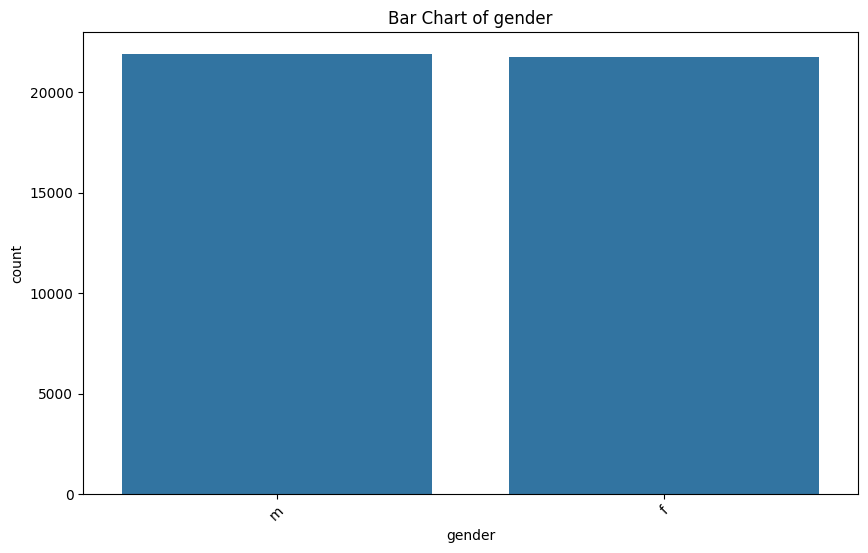

In [8]:
# Bar charts for categorical variables
categorical_columns = bankInfo.select_dtypes(include=['object', 'category']).columns
for col in categorical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=bankInfo[col])
    plt.title(f'Bar Chart of {col}')
    plt.xticks(rotation=45)
    plt.show()

In [23]:
# How many numeric columns are in the data set?
num_numeric_columns = bankInfo.select_dtypes(include=['number']).shape[1]
print (num_numeric_columns)

5


In [26]:
# Normalization
scaler = MinMaxScaler()
bankInfo[bankInfo.select_dtypes(include=['number']).columns] = scaler.fit_transform(bankInfo.select_dtypes(include=['number']))

In [27]:
# Likely need to convert categorical columns to category dtype
for col in bankInfo.select_dtypes(include=['object']).columns:
    bankInfo[col] = bankInfo[col].astype('category')   

In [30]:
# Creating dummy variables, make sure the variables that need to be converted to dummies are categorical, not numeric.
# This might require you to convert some columns to categorical first using astype('category')
bankInfo_dummies = pd.get_dummies(bankInfo, drop_first=True)

In [31]:
print(bankInfo.shape)
print(bankInfo_dummies.shape)

(43628, 13)
(43628, 29)


In [29]:
# Display missing data using the isnull function, is there any missing data?
print(bankInfo.isnull().sum())

age             0
job             0
marital         0
education       0
race            0
default         0
balance         0
housing         0
contact         0
duration        0
contactndays    0
signed up       0
gender          0
dtype: int64


In [32]:
# remove missing values if needed
bankInfo = bankInfo.dropna()

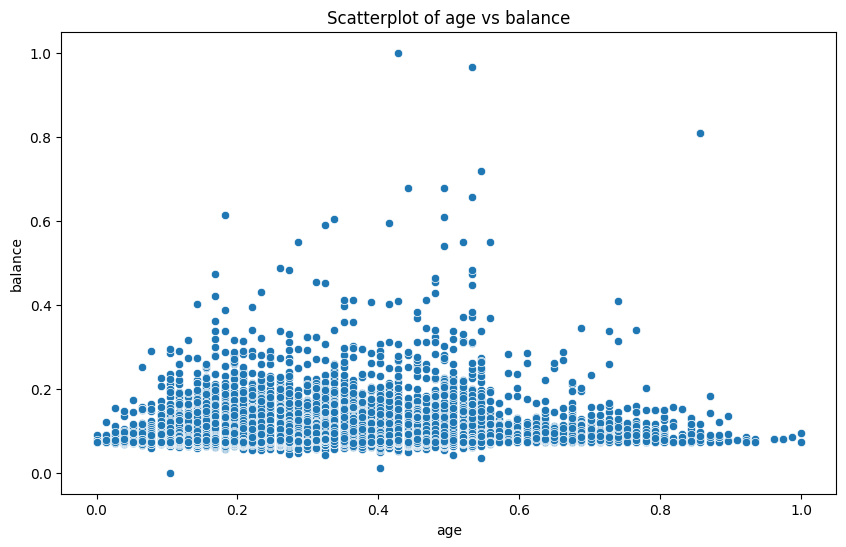

In [20]:
# Scatterplot between two continuous variables
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='balance', data=bankInfo)  # Replace 'Variable1' and 'Variable2' with your column names
plt.title('Scatterplot of age vs balance')
plt.savefig('scatterplot.png')  # Save the scatterplot image
plt.show()

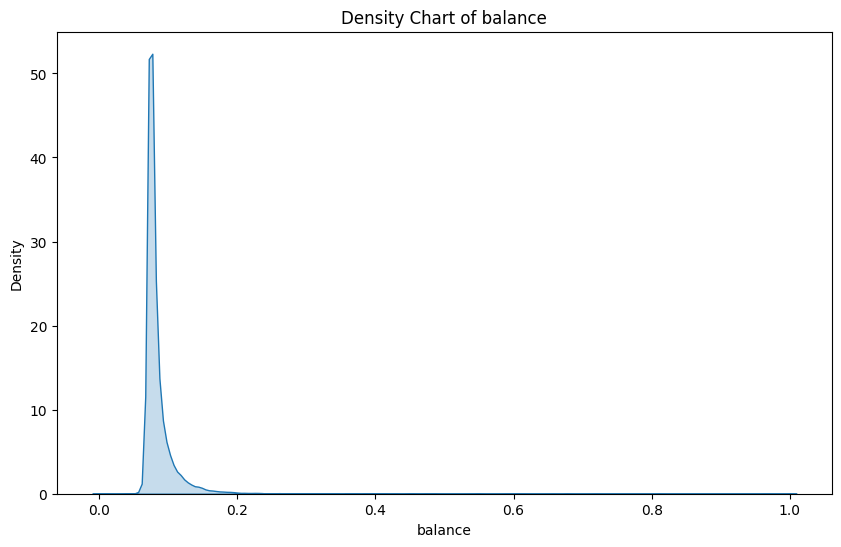

In [28]:
# Density chart of a continuous variable
plt.figure(figsize=(10, 6))
sns.kdeplot(bankInfo['balance'], fill=True)  # Replace 'ContinuousVariable' with your column name
plt.title('Density Chart of balance')
plt.show()

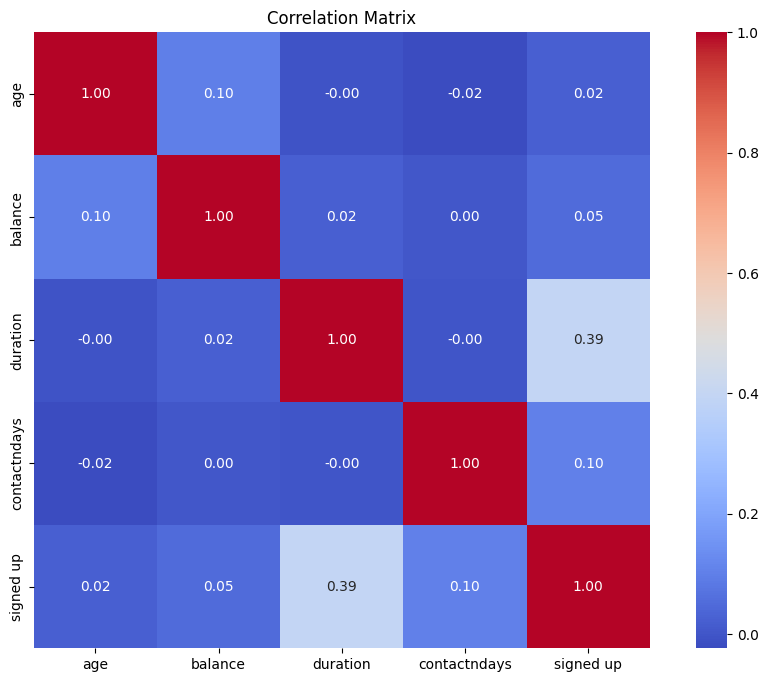

In [34]:
#Correlation matrix, make sure to only include numeric variables
num_values = bankInfo.select_dtypes(include=['number'])
correlation_matrix = num_values.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

## Analytics: Build a model and Tune it for best Best Performance

In [37]:
# What is the ‘target’ of a model and what is the prevalence of the target in your dataset? Remember prevalence 
# is the proportion of records that take on the value of interest for the target variable, usually the positive class.
target_prevalence = bankInfo['signed up'].sum()  # Replace 'TargetVariable' with your target column name
print(f'Target Prevalence: {target_prevalence}')

Target Prevalence: 5074.0


In [39]:
# Divide the dataset into features and target
target = bankInfo_dummies['signed up']  # Replace 'TargetVariable' with your actual target column name and "xx" with your dataframe name
features = bankInfo_dummies.drop(columns=['signed up']) # Drop the target column from features
print(features.shape)

(43628, 28)


In [40]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [41]:
# Include your table for the 10 values of k you tried and the corresponding accuracies.

accuracy_results = {}

# Replace x with your desired range values, explain what is happening in this loop
for k in range(1, 11):  
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    accuracy = knn_model.score(X_test, y_test)
    accuracy_results[k] = accuracy

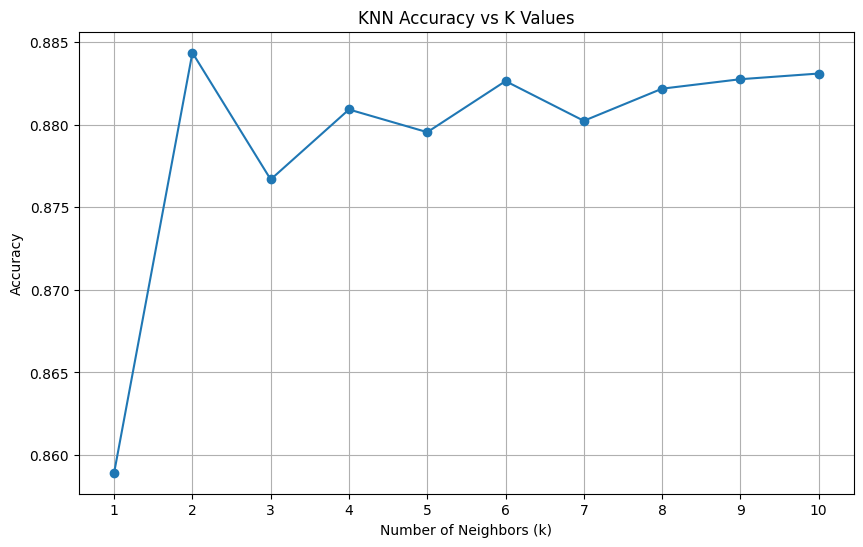

In [42]:
#graph of accuracy vs k values
plt.figure(figsize=(10, 6))
plt.plot(list(accuracy_results.keys()), list(accuracy_results.values()), marker='o')
plt.title('KNN Accuracy vs K Values')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(list(accuracy_results.keys()))
plt.grid()
plt.show()

In [43]:
# using the hyperparameter k that gave the best accuracy, rerun the model and generate 
# predictions on the test set. Explain why you choose this k value.
best_k = 2  # Replace 'xx' with the best k value found
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)  

## Value: Evaluation and Protected Classes

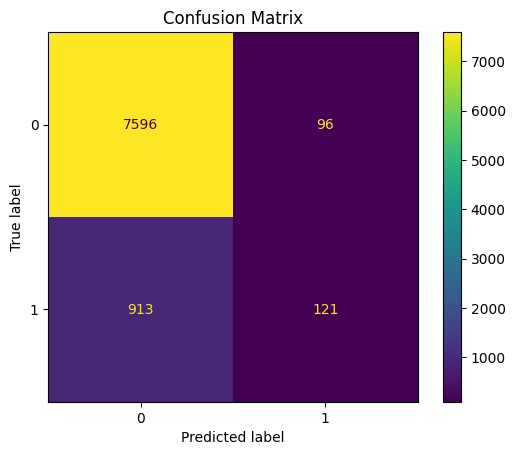

In [44]:
# create a confusion matrix for your model's predictions. 
# What does the confusion matrix tell you about your model's performance?
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

In [46]:
print(X_test.columns)

Index(['age', 'balance', 'duration', 'contactndays', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_married', 'marital_single',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'race_black', 'race_hispanic', 'race_white', 'default_yes',
       'housing_yes', 'contact_telephone', 'contact_unknown', 'gender_m'],
      dtype='str')


In [47]:
#We already have a model above using KNN so we can use the results to compute fairness metrics

# Compute fairness metrics using Fairlearn

my_metrics = {
    'true positive rate' : true_positive_rate,
    'false positive rate' : false_positive_rate,
    'selection rate' : selection_rate,
    'count' : count
}
# Construct a MetricFrame for race
mf_race = MetricFrame(
    metrics=my_metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=X_test[['race_black', 'race_hispanic', 'race_white']]  # Replace with your first protected class
)

# Construct a MetricFrame for gender
mf_gender = MetricFrame(
    metrics=my_metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=X_test['gender_m']  # Replace second protected class 
)  


In [48]:
mf_race.by_group #What do the results show? Change the mf_race with each subgroup and report the findings. This means
# you should run this cell multiple times, once for each of the levels in the race variable.

true positive rate  false positive rate  \
race_black race_hispanic race_white                                            
False      False         False                 0.088462             0.012712   
                         True                  0.120567             0.014440   
           True          False                 0.111538             0.011665   
                         True                       NaN                  NaN   
True       False         False                 0.150862             0.011117   
                         True                       NaN                  NaN   
           True          False                      NaN                  NaN   
                         True                       NaN                  NaN   

                                     selection rate   count  
race_black race_hispanic race_white                          
False      False         False             0.021881  2148.0  
                         True              0.027915  2221.0  
           True          False             0.023765  2146.0  
                         True                   NaN     NaN  
True       False         False             0.025780  2211.0  
                         True                   NaN     NaN  
           True          False                  NaN     NaN  
                         True                   NaN     NaN

In [49]:
mf_gender.by_group #What do the results show? There's only two groups here so we don't need to change anything. 
# in the metric frame.

,true positive rate,false positive rate,selection rate,count
gender_m,,,,
False,0.117117,0.012645,0.025971,4351.0
True,0.116910,0.012320,0.023771,4375.0


In [50]:
# Derived fairness metrics. Be sure you understand the scale and meaning of these. Here we are calculating the 
# two fairness ratios using the gender_m feature, which is bi-variate. What do the results show, is the model more or 
# less fair with this grouping?

dpr_gender = fairlearn.metrics.demographic_parity_ratio(y_test, y_pred, sensitive_features=X_test['gender_m'])
print("Demographic Parity ratio:\t", dpr_gender)

eodds_gender = fairlearn.metrics.equalized_odds_ratio(y_test, y_pred, sensitive_features=X_test['gender_m'])
print("Equalized Odds ratio:\t\t", eodds_gender)

Demographic Parity ratio:	 0.915305183312263
Equalized Odds ratio:		 0.9743326488706366


In [51]:
# Derived fairness metrics. Be sure you understand the scale and meaning of these. Here we are calculating the 
# the same features above only using a filtered search to pull in all the possibilities of features
# starting with "race". What do the results show, is the model more or less fair with this grouping?

dpr_race = fairlearn.metrics.demographic_parity_ratio(y_test, y_pred, sensitive_features=X_test.filter(regex="race.*"))
print("Demographic Parity ratio:\t", dpr_race)

eodds_race = fairlearn.metrics.equalized_odds_ratio(y_test, y_pred, sensitive_features=X_test.filter(regex="race.*"))
print("Equalized Odds ratio:\t\t", eodds_race)

Demographic Parity ratio:	 0.7838274163512946
Equalized Odds ratio:		 0.5863736263736264


In [ ]:
#Optional code to add, commit, and push changes to your GitHub repository
!git add .
!git commit -m "Insert Message Here" # This will commit your changes to git. 
!git push # This will push your changes to back to your remote repository on GitHub.